# Name  : H.K. Sashika Chamindi
# Date  : 2026.03.07
# Topic : PCA (Principal Component Analysis) for Visualization

# How to Convert 2D Array to 1D

In [1]:
# import necerssary libraries
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Create dataset as a NumPy array
# Each row represents a student
# Column 1 = Maths Marks
# Column 2 = Science Marks
data = np.array([[40, 20],
                [55, 30],
                [70, 60],
                [50, 35],
                [45, 40],
                [62, 75],
                [45, 30],
                [68, 80],
                [80, 70],
                [75, 90]])

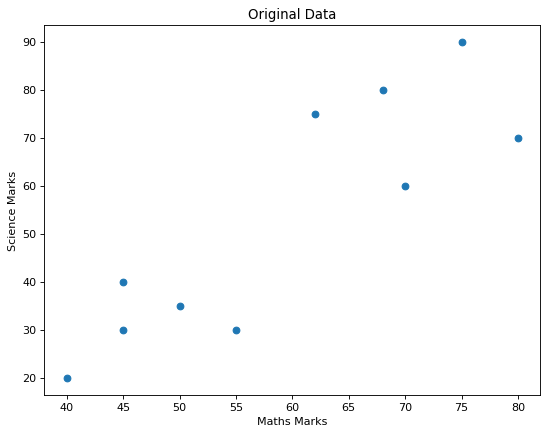

In [3]:
# Plot the original data points
# X-axis = Maths Marks
# Y-axis = Science Marks
from matplotlib.pyplot import figure
figure(figsize=(8, 6), dpi=80)
plt.scatter(data[:, 0], data[:, 1])
plt.xlabel("Maths Marks")
plt.ylabel("Science Marks")
plt.title("Original Data")
plt.show()

In [4]:
# -----------------------------------
# STANDARDIZATION (Feature Scaling)
# -----------------------------------

from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Fit and transform the data
# This converts data to mean = 0 and standard deviation = 1
scaled_data = scaler.fit_transform(data)

# Print scaled data
print(scaled_data)

[[-1.43299332 -1.39951173]
 [-0.3016828  -0.97541727]
 [ 0.82962771  0.29686613]
 [-0.67878631 -0.76337004]
 [-1.05588981 -0.5513228 ]
 [ 0.2262621   0.93300782]
 [-1.05588981 -0.97541727]
 [ 0.67878631  1.14505506]
 [ 1.58383472  0.72096059]
 [ 1.20673122  1.56914952]]


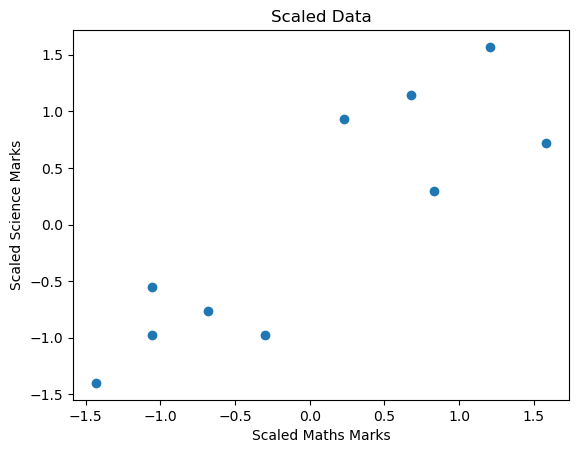

In [5]:
# Plot scaled data
plt.scatter(scaled_data[:, 0], scaled_data[:, 1])
plt.xlabel("Scaled Maths Marks")
plt.ylabel("Scaled Science Marks")
plt.title("Scaled Data")
plt.show()

In [6]:
# -----------------------------------
# PCA (Principal Component Analysis)
# -----------------------------------

from sklearn.decomposition import PCA

In [7]:
# Create PCA object with 2 components
# (Same as original dimension, just to check variance)
pca = PCA(n_components=2)

In [8]:
# Fit PCA on scaled data
pca.fit(scaled_data)

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [9]:
# Check variance captured by each principal component
print("Explained Variance:", pca.explained_variance_)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance: [2.07778406 0.14443817]
Explained Variance Ratio: [0.93500282 0.06499718]


In [10]:
# Here we can see that first component captures ~94% variance

In [11]:
# Now reduce dimension from 2D → 1D
pca = PCA(n_components=1)
pca.fit(scaled_data)

,n_components,1
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [12]:
# Check variance captured by principal component
print("Explained Variance:", pca.explained_variance_)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance: [2.07778406]
Explained Variance Ratio: [0.93500282]


In [13]:
# Transform data into 1 principal component
pca_scaled_data = pca.transform(scaled_data)

In [14]:
# Dimensions of the scaled data (rows,columns)
scaled_data.shape

(10, 2)

In [15]:
# Dimensions of scaled data after using PCA (rows,columns)
pca_scaled_data.shape

(10, 1)

In [16]:
# -----------------------------------
# Reconstructing Data
# -----------------------------------

# Convert 1D data back to 2D approximation
# (This is an approximate reconstruction)
pca_scaled_data = pca.inverse_transform(pca_scaled_data)

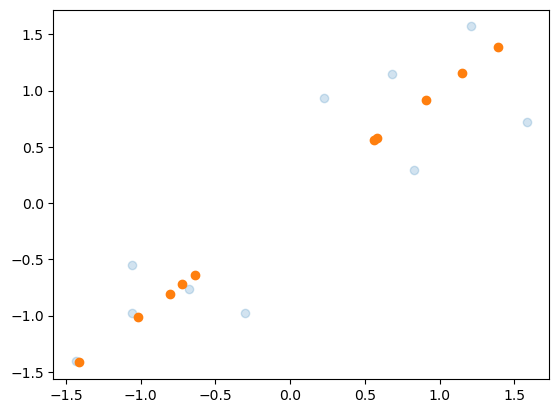

In [17]:
# scaled data (light color)
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], alpha=0.2)

# Reconstructed data (after PCA)
plt.scatter(pca_scaled_data[:, 0], pca_scaled_data[:, 1])

## Visualizing and Reducing the Number of Dimensions in a High-Dimensional Dataset Using PCA

In [18]:
# Import the digits dataset from scikit-learn
from sklearn.datasets import load_digits

# Load the digits dataset
digits = load_digits()

In [19]:
# Check the shape of the data
print(digits.data.shape)

(1797, 64)


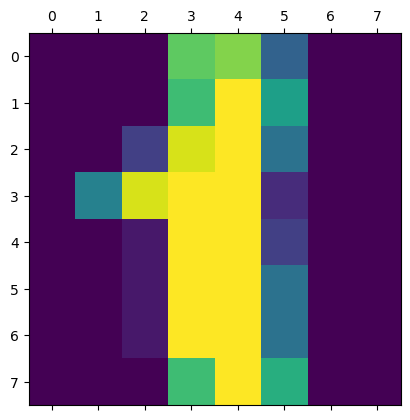

In [20]:
# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Visualize the second digit image (index 1)
plt.matshow(digits.images[1])  # Show as a matrix/image
plt.show()  # Display the plot

In [21]:
# Check the actual label of the second image
print(digits.target[1])  # Output: 1

1


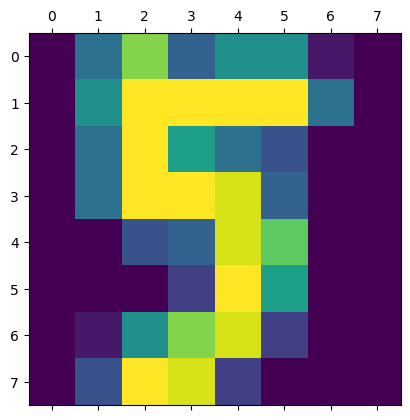

In [22]:
# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Visualize the 34th digit image (index 33)
plt.matshow(digits.images[33])  # Show as a matrix/image
plt.show()  # Display the plot

In [23]:
# Check the actual label of the 34th image
print(digits.target[33])  # Output: 5

5


In [24]:
# Import PCA (Principal Component Analysis) from scikit-learn
from sklearn.decomposition import PCA

# Initialize PCA to reduce data from 64 dimensions to 2 dimensions
# This is useful for visualization
pca = PCA(n_components=2)

# Fit PCA on the digits data and transform it into 2D
# digits.data has shape (1797, 64), new_data will have shape (1797, 2)
new_data = pca.fit_transform(digits.data)

# Print the original data shape (number of samples, number of features)
print(digits.data.shape)  # Output: (1797, 64)

# Print the transformed data shape (number of samples, 2 principal components)
print(new_data.shape)     # Output: (1797, 2)

(1797, 64)
(1797, 2)


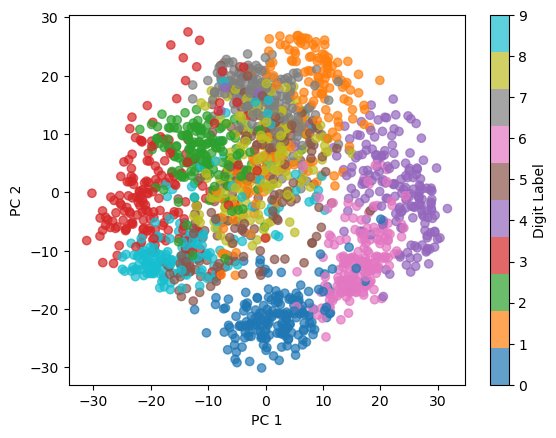

In [25]:
# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Create a scatter plot of the 2D PCA-transformed data
# new_data[:, 0] -> x-axis (Principal Component 1)
# new_data[:, 1] -> y-axis (Principal Component 2)
# c=digits.target -> color points based on their actual digit labels (0-9)
plt.scatter(new_data[:, 0], new_data[:, 1], c=digits.target, cmap='tab10', alpha=0.7)

# Label the x-axis as 'PC 1' (Principal Component 1)
plt.xlabel('PC 1')

# Label the y-axis as 'PC 2' (Principal Component 2)
plt.ylabel('PC 2')

# Add a colorbar to show which color corresponds to which digit
plt.colorbar(label='Digit Label')

# Display the plot
plt.show()

## PCA for speedup models

In [26]:
from sklearn.datasets import load_digits
import numpy as np

In [27]:
digits = load_digits()
digits.data.shape

(1797, 64)

In [28]:
# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
sc = StandardScaler()

# Scale the data: mean = 0, variance = 1
new_data = sc.fit_transform(digits.data)

In [29]:
# divide dataset into training and testing set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(new_data, digits.target, test_size=0.2, random_state=42)


In [30]:
x_train.shape

(1437, 64)

In [31]:
x_test.shape

(360, 64)

In [32]:
# Import Logistic Regression from scikit-learn
from sklearn.linear_model import LogisticRegression

# Initialize the model
# solver='lbfgs' is good for small datasets, max_iter=1000 ensures convergence
model = LogisticRegression(solver='lbfgs', max_iter=1000)

# Import time module to measure training time
import time

# Record start time
start = time.time()

# Train the model on training data
model.fit(x_train, y_train)

# Record end time
end = time.time()

# Print the training time in milliseconds
print('Time: ' + str((end - start)*1000) + ' ms')

Time: 27.0998477935791 ms


In [33]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(x_test)
accuracy_score(y_test, y_pred)

0.9722222222222222

In [34]:
from sklearn.decomposition import PCA
pca = PCA(n_components=10)
new_data_pca = pca.fit_transform(new_data)

In [35]:
new_data_pca.shape

(1797, 10)

In [36]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(new_data_pca, digits.target, test_size=0.2, random_state=42)

In [37]:
x_train.shape

(1437, 10)

In [38]:
x_test.shape

(360, 10)

In [39]:
# import logistic regression to train the model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='lbfgs', max_iter=1000)

In [40]:
# calculate time
import time
start = time.time()
model.fit(x_train, y_train)
end = time.time()

print('Time: ' + str((end - start)*1000) + ' ms')

Time: 41.41974449157715 ms


In [41]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(x_test)
accuracy_score(y_test, y_pred)

0.8972222222222223